In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from scipy.integrate import solve_ivp
import timeit
from scipy.sparse import csr_array,block_array,eye,coo_array
import subprocess

loadstr=''
try:
    loadstr='module load %s &&'%(subprocess.check_output("module avail | grep cuda/", shell=True, text=True).split()[-1])
except:
    pass

Define coupling parameters for CGLE

$$
\frac{\partial A}{\partial t} = A + (1+ib)\nabla^2 A - (1-ic)|A|^2 A,
$$

which we separate into real and imaginary parts $A=X+iY$ with


$$
\frac{\partial X}{\partial t} = X + \nabla^2 X - b \nabla^2 Y - (X^2+Y^2)X - c (X^2+Y^2)Y, 
$$

$$
\frac{\partial Y}{\partial t} = Y + \nabla^2 Y + b \nabla^2 X - (X^2+Y^2)Y + c (X^2+Y^2)X.
$$

We can find the indices for the coupling terms with the help function with no filebase.

In [2]:
Ns=[256,256]
N=Ns[0]*Ns[1]
Ls=[100.0,100.0]
T=10
cmd='module load cuda && ./rdcu -N %i,%i -L %f,%f -n 2 -h'%(Ns[0],Ns[1],Ls[0],Ls[1])
print(cmd)
os.system(cmd)

module load cuda && ./rdcu -N 256,256 -L 100.000000,100.000000 -n 2 -h
usage:	rdcu [-hvSFR] [-n NFIELDS] [-N NUMS] [-L LENGTHS]
	[-c COUPLING] [-A AMPLITUDE] [-t TIME] [-d DT] [-s SEED] 
	[-D DENSITY] [-g GPU] [-r RTOL] [-a ATOL]  FILEBASE 

-h for help. Call with -n and -N to see Y indices. 
-v for verbose output, including progress 
-S for stiff system. Use the BDF method with finite differences instead of RK45 pseudospectral method. 
-F for fixed timestep 
-R to reload final state from FILEBASEfs.dat if possible
NFIELDS is the number of fields. Default 1
NUMS is number of grid points in each dimension (up to three), separated by commas (no spaces). Default 128
LENGTHS is domain length in each dimension (up to three), separated by commas (no spaces). Default 1.0
COUPLING is a list of coupling terms, separated by commas (no spaces). Default empty
	The first value is the term coefficent. 
	The second value is an integer specifying the field that the term appears in. 
	The following 2N 

0

In [3]:
filebase='data/2dcgle'

b=2.0 
c=0.8
couplings=['1.0,0,0,1', '1.0,0,6,1', '1.0,0,12,1', '-%f,0,7,1'%(b), \
           '-%f,0,13,1'%(b), '-1.0,0,0,3', '-1.0,0,0,1,1,2', '1.0,1,1,1', \
           '1.0,1,7,1', '1.0,1,13,1', '%f,1,6,1'%(b),'%f,1,12,1'%(b), \
           '-1.0,1,0,2,1,1', '-1.0,1,1,3', '%f,1,0,3'%(c), '%f,1,0,1,1,2'%(c), \
           '-%f,0,0,2,1,1'%(c),'-%f,0,1,3'%(c)]

file=open('%scoupling.dat'%(filebase),'w')
for line in couplings:
    print(line,file=file)
file.close()

Explicit runge-kutta pseudospectral on the gpu

In [4]:
cmd='module load cuda && ./rdcu -t %f -d 0.1 -N %i,%i -L %f,%f -n 2 -v -D1 %s'%(T,Ns[0],Ns[1],Ls[0],Ls[1],filebase)
print(cmd)
os.system(cmd)

module load cuda && ./rdcu -t 10.000000 -d 0.1 -N 256,256 -L 100.000000,100.000000 -n 2 -v -D1 data/2dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Using random initial conditions
1.000	2.761e+00	-2.557e-04	0.010712	924	
runtime: 2.764035


0

runtime: 2.764035



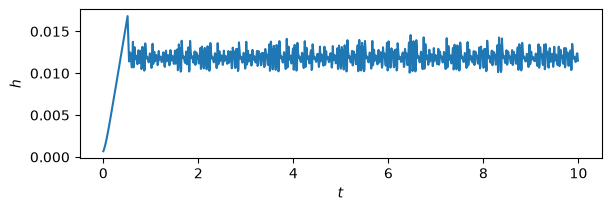

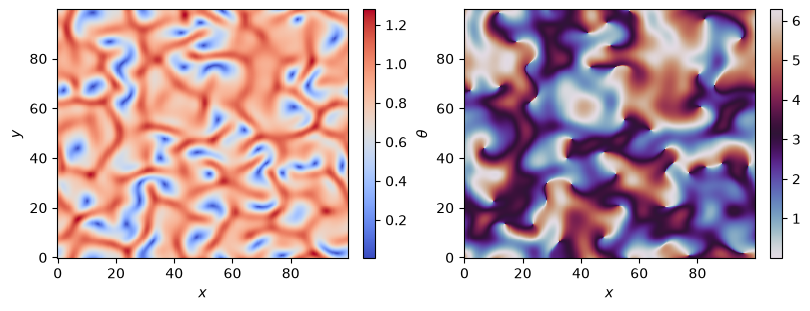

In [5]:
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
U0=ys[0].reshape(-1)
ts=np.fromfile(filebase+'times.dat')

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()


implicit BDF with finite differences on gpu with the same initial condition. Note the first few timesteps are small before the BDF stabilizes.

In [6]:
cmd='module load cuda && ./rdcu -t %f -d 0.1,0.01 -N %i,%i -L %f,%f -n 2 -v -S -D1 %s'%(T,Ns[0],Ns[1],Ls[0],Ls[1], filebase)
print(cmd)
os.system(cmd)

module load cuda && ./rdcu -t 10.000000 -d 0.1,0.01 -N 256,256 -L 100.000000,100.000000 -n 2 -v -S -D1 data/2dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Using random initial conditions
1.003	5.147e+00	-1.418e-02	0.035731	630	
runtime: 5.160200


0

runtime: 5.160200



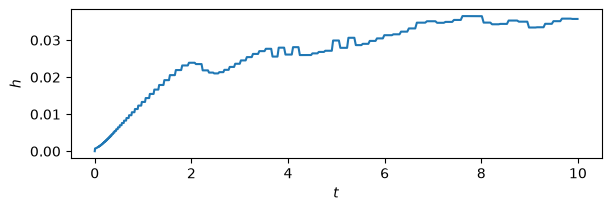

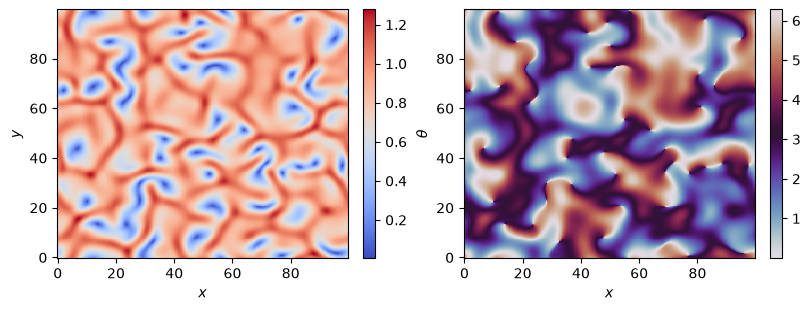

In [7]:
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()


Explicit runge-kutta pseudospectral on the cpu. The GPU results are almost identical and much faster, and performance benefits increase with increasing Ns.

In [8]:
def lap(y,Ls,Ns):
    yfft=np.fft.fftn(y)
    ret=-np.fft.fftfreq(Ns[0],Ls[0]/(2*np.pi*Ns[0])).reshape((Ns[0],1))**2*yfft
    ret=ret-np.fft.fftfreq(Ns[1],Ls[1]/(2*np.pi*Ns[1])).reshape((1,Ns[1]))**2*yfft
    return np.fft.ifftn(ret)

def cgle(t, U, b, c, Ls, Ns):
    N=Ns[0]*Ns[1]
    X=U[:N].reshape(Ns)
    Y=U[N:].reshape(Ns)
    A=X+1j*Y
    lapA=lap(A,Ls,Ns)
    lapX=np.real(lapA)
    lapY=np.imag(lapA)
    retX=X+lapX-b*lapY-(X**2+Y**2)*(X+c*Y)
    retY=Y+lapY+b*lapX-(X**2+Y**2)*(Y-c*X)
    ret=np.zeros(U.shape)
    ret[:N]=retX.reshape(-1)
    ret[N:]=retY.reshape(-1)
    return ret

start=timeit.default_timer()
sol1=solve_ivp(cgle,[0,T],U0,args=[b,c,Ls,Ns],method='RK45',rtol=1E-8,atol=1E-8,first_step=0.03)
stop=timeit.default_timer()
print("runtime: ", stop-start, flush=True)

ys=sol1.y.reshape([2]+Ns+[-1]).transpose(3,0,1,2)
ts=sol1.t

runtime:  16.45063720177859


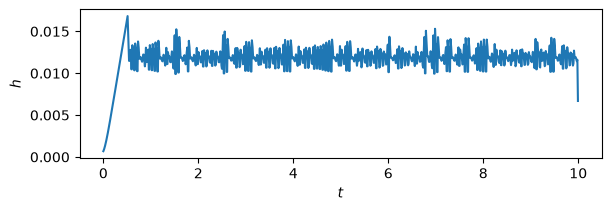

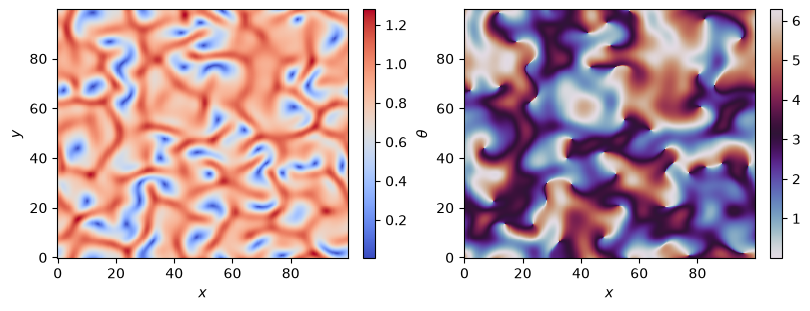

In [9]:
ys=sol1.y.reshape([2]+Ns+[-1]).transpose(3,0,1,2)
ts=sol1.t

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()


implicit BDF with finite differences on cpu. The GPU results are again almost identical and are comparatively even faster. The sparse LU solver from scipy performs poorly compared to cudss and scales very poorly with increasing Ns.

In [10]:
def lap(y,Ls,Ns):
    return (np.roll(y,1,axis=0)+np.roll(y,-1,axis=0)-2*y)/(Ls[0]/Ns[0])**2+(np.roll(y,1,axis=1)+np.roll(y,-1,axis=1)-2*y)/(Ls[1]/Ns[1])**2

def cgle(t, U, b, c, Ls, Ns, I, JI):
    N=Ns[0]*Ns[1]
    X=U[:N].reshape(Ns)
    Y=U[N:].reshape(Ns)
    A=X+1j*Y
    lapA=lap(A,Ls,Ns)
    lapX=np.real(lapA)
    lapY=np.imag(lapA)
    retX=X+lapX-b*lapY-(X**2+Y**2)*(X+c*Y)
    retY=Y+lapY+b*lapX-(X**2+Y**2)*(Y-c*X)
    ret=np.zeros(U.shape)
    ret[:N]=retX.reshape(-1)
    ret[N:]=retY.reshape(-1)
    return ret

def jac(t, U, b, c, Ls, Ns, I, JI):
    N=Ns[0]*Ns[1]
    X=U[:N]
    Y=U[N:]
#     retX=X+lapX-b*lapY-(X**2+Y**2)*(X+c*Y)
    retXX=I+JI-(2*X*I)*(X+c*Y)-(X**2+Y**2)*I
    retXY=-b*JI-(2*Y*I)*(X+c*Y)-(X**2+Y**2)*I*c
#     retY=Y+lapY+b*lapX-(X**2+Y**2)*(Y-c*X)
    retYX=b*JI-(2*X*I)*(Y-c*X)+(X**2+Y**2)*I*c
    retYY=I+JI-(2*Y*I)*(Y-c*X)-(X**2+Y**2)*I
    return block_array([[retXX,retYX],[retXY, retYY]]).T


I=csr_array(eye(N))
coords=I.reshape(Ns+Ns).coords
data=I.reshape(Ns+Ns).data
Ip0=coo_array((data,(coords[0],coords[1],np.roll(coords[2],Ns[0]),coords[3])),Ns+Ns).reshape(N,N)
Ip1=coo_array((data,(coords[0],coords[1],coords[2],np.roll(coords[3],1))),Ns+Ns).reshape(N,N)
Im0=coo_array((data,(coords[0],coords[1],np.roll(coords[2],-Ns[0]),coords[3])),Ns+Ns).reshape(N,N)
Im1=coo_array((data,(coords[0],coords[1],coords[2],np.roll(coords[3],-1))),Ns+Ns).reshape(N,N)
JI=(Ip0+Im0-2*I)/(Ls[0]/Ns[0])**2+(Ip1+Im1-2*I)/(Ls[1]/Ns[1])**2

start=timeit.default_timer()
sol2=solve_ivp(cgle,[0,T],U0,args=[b,c,Ls,Ns,I,JI],method='BDF',jac=jac,rtol=1E-8,atol=1E-8)
stop=timeit.default_timer()
print("runtime: ", stop-start, flush=True)

runtime:  800.0861131548882


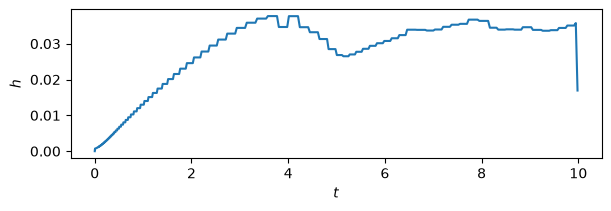

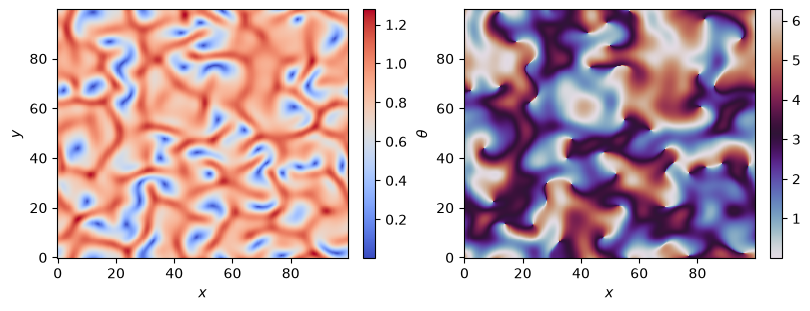

In [11]:
ys=sol2.y.reshape([2]+Ns+[-1]).transpose(3,0,1,2)
ts=sol2.t

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()


Note that BDF takes larger steps that RK45. As the number of mesh points Ns increases, the system gets stiffer and RK45 takes increasingly smaller steps while BDF does not. The sparse LU scales well enough that BDF outperforms RK45 for large Ns.  Even though the pseudospectral discretization is generally superior to finite difference, BDF may be preferred for fine spatial resolution. Illustrate with a large system size.

In [12]:
Ns=[1024,1024]

cmd='module load cuda && ./rdcu -t %f -d 0.1 -N %i,%i -L %f,%f -n 2 -v -D1 %s'%(T,Ns[0],Ns[1],Ls[0],Ls[1],filebase)
print(cmd)
os.system(cmd)

module load cuda && ./rdcu -t 10.000000 -d 0.1 -N 1024,1024 -L 100.000000,100.000000 -n 2 -v -D1 data/2dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Using random initial conditions
1.000	1.474e+02	-3.076e-03	0.000741	13614	
runtime: 147.454986


0

runtime: 147.454986



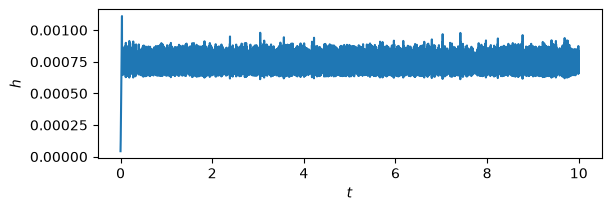

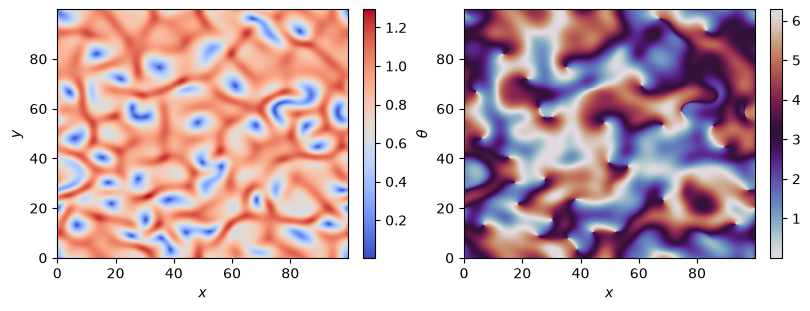

In [13]:
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()


In [14]:
Ns=[1024,1024]

cmd='module load cuda && ./rdcu -t %f -d 0.1 -N %i,%i -L %f,%f -S -n 2 -v -D1 %s'%(T,Ns[0],Ns[1],Ls[0],Ls[1],filebase)
print(cmd)
os.system(cmd)

module load cuda && ./rdcu -t 10.000000 -d 0.1 -N 1024,1024 -L 100.000000,100.000000 -S -n 2 -v -D1 data/2dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Using random initial conditions
1.003	4.838e+01	-1.268e-01	0.035411	779	
runtime: 48.538202


0

runtime: 48.538202



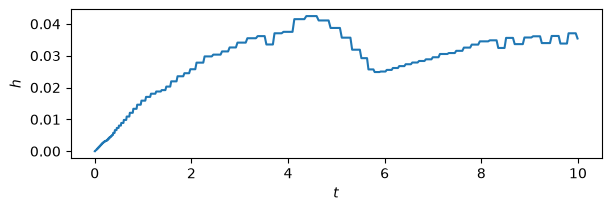

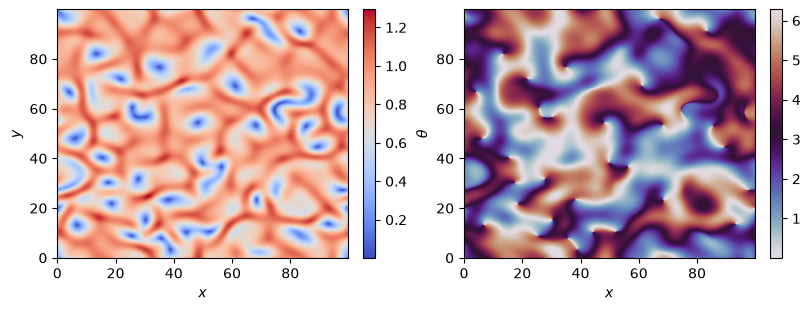

In [15]:
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()

For both integration methods, we can reload saved final states in FILEBASEfs.dat with the -R flag to continue

In [16]:
cmd='module load cuda && ./rdcu -t %f -d 0.1 -N %i,%i -L %f,%f -R -S -n 2 -v -D1 %s'%(2*T,Ns[0],Ns[1],Ls[0],Ls[1],filebase)
print(cmd)
os.system(cmd)

module load cuda && ./rdcu -t 20.000000 -d 0.1 -N 1024,1024 -L 100.000000,100.000000 -R -S -n 2 -v -D1 data/2dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Reloading final conditions from file
Restarting at t=10.026377 with h=0.035411
1.002	2.720e+01	-6.166e-02	0.035654	273	
runtime: 27.337188


0

runtime: 27.337188



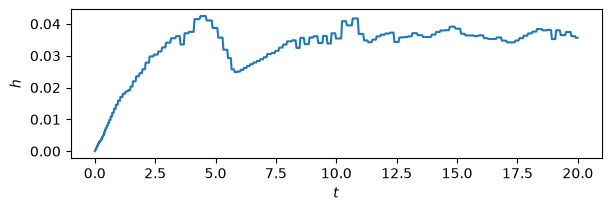

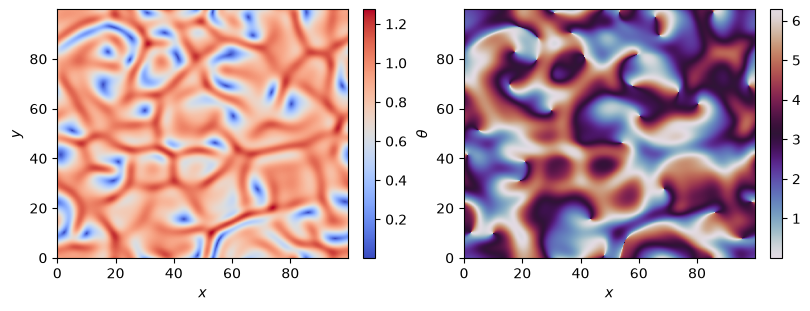

In [17]:
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()


1D CGLE

In [18]:
Ns=[8192]
N=Ns[0]
Ls=[200.0]
T=100

filebase='data/1dcgle'

b=2.0 
c=0.8
couplings=['1.0,0,0,1', '1.0,0,4,1', '-%f,0,5,1'%(0*b),  \
           '-1.0,0,0,3', '-1.0,0,0,1,1,2', '1.0,1,1,1', \
           '1.0,1,5,1', '%f,1,4,1'%(0*b), \
           '-1.0,1,0,2,1,1', '-1.0,1,1,3', '%f,1,0,3'%(4*c), '%f,1,0,1,1,2'%(4*c), \
           '-%f,0,0,2,1,1'%(4*c),'-%f,0,1,3'%(4*c)]

file=open('%scoupling.dat'%(filebase),'w')
for line in couplings:
    print(line,file=file)
file.close()

cmd='module load cuda && ./rdcu -t %f -d 0.1 -N %i -L %f -n 2 -v -D1 -S %s'%(T,Ns[0],Ls[0],filebase)
print(cmd)
os.system(cmd)

module load cuda && ./rdcu -t 100.000000 -d 0.1 -N 8192 -L 200.000000 -n 2 -v -D1 -S data/1dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + -0.000(u1_00)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -3.200(u0)^2(u1)^1 + -3.200(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 0.000(u0_00)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 3.200(u0)^3 + 3.200(u0)^1(u1)^2 + 0
Using random initial conditions
1.000	8.152e+00	-8.116e-04	0.019039	5409	
runtime: 8.154569


0

runtime: 8.154569



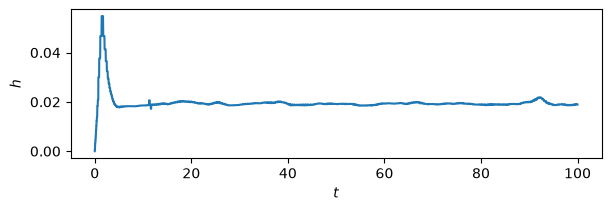

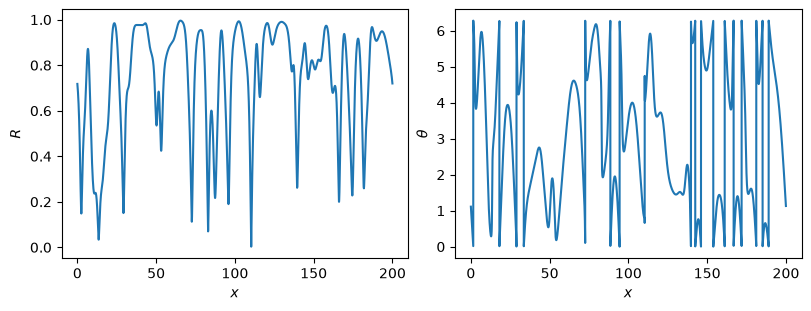

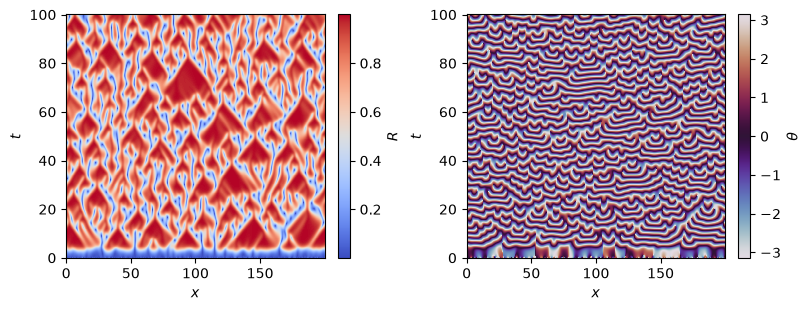

In [19]:
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.plot(np.arange(Ns[0])/Ns[0]*Ls[0], R)
ax.set_xlabel('$x$')
ax.set_ylabel('$R$')

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.plot(np.arange(Ns[0])/Ns[0]*Ls[0], R)
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')

plt.show()

fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[:,0]**2+ys[:,1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(ys.shape[0])*0.1, R,cmap='coolwarm')
plt.xlabel(r'$x$')
plt.ylabel(r'$t$')
plt.colorbar(label=r'$R$')

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[:,1],ys[:,0])

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(ys.shape[0])*0.1, R,cmap='twilight')
plt.xlabel(r'$x$')
plt.ylabel(r'$t$')
plt.colorbar(label=r'$\theta$')

plt.show()

3d CGLE

In [20]:
# Ns=[256,256,256]
Ns=[128,128,128]
N=Ns[0]
Ls=[100.0,100.0,100.0]
T=10


filebase='data/3dcgle'

b=2.0 
c=0.8
couplings=['1.0,0,0,1', '1.0,0,8,1', '1.0,0,16,1', '1.0,0,24,1', '-%f,0,9,1'%(b), \
           '-%f,0,17,1'%(b), '-%f,0,25,1'%(b), '-1.0,0,0,3', '-1.0,0,0,1,1,2', '1.0,1,1,1', \
           '1.0,1,9,1', '1.0,1,17,1', '1.0,1,25,1', '%f,1,8,1'%(b),'%f,1,16,1'%(b), '%f,1,24,1'%(b), \
           '-1.0,1,0,2,1,1', '-1.0,1,1,3', '%f,1,0,3'%(c), '%f,1,0,1,1,2'%(c), \
           '-%f,0,0,2,1,1'%(c),'-%f,0,1,3'%(c)]

file=open('%scoupling.dat'%(filebase),'w')
for line in couplings:
    print(line,file=file)
file.close()

In [21]:
cmd='module load cuda && ./rdcu -t %f -d 0.1 -N %i,%i,%i -L %f,%f,%f -n 2 -v -D1 %s'%(T,Ns[0],Ns[1],Ns[2],Ls[0],Ls[1],Ls[2],filebase)
print(cmd)
os.system(cmd)

module load cuda && ./rdcu -t 10.000000 -d 0.1 -N 128,128,128 -L 100.000000,100.000000,100.000000 -n 2 -v -D1 data/3dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + 1.000(u0_22)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -2.000(u1_22)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 1.000(u1_22)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + 2.000(u0_22)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Using random initial conditions
1.002	2.439e+01	-4.257e-02	0.030222	395	
runtime: 24.480885


0

runtime: 24.480885



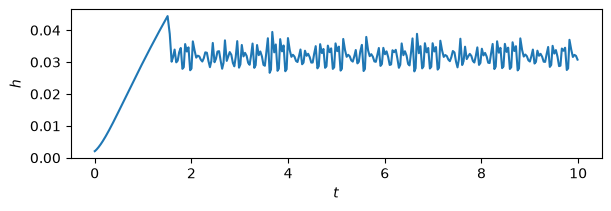

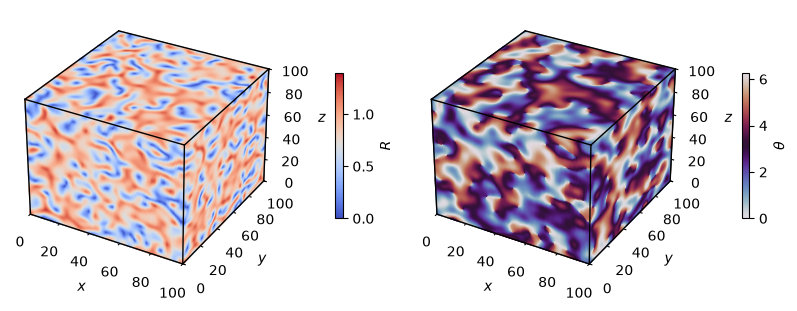

In [22]:
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1, projection='3d')

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5
Rmax=np.max(R)

Y,X=np.meshgrid(np.arange(Ns[0])/Ns[0]*Ls[0],np.arange(Ns[1])/Ns[1]*Ls[1])
Z=Ls[2]*np.ones(X.shape)
C=plt.get_cmap('coolwarm')(R[:,:,-1]/Rmax)
ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)

X,Z=np.meshgrid(np.arange(Ns[0])/Ns[0]*Ls[0],np.arange(Ns[2])/Ns[2]*Ls[2])
Y=0*np.ones(X.shape)
C=plt.get_cmap('coolwarm')(R[:,0,:].T/Rmax)
ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)

Z,Y=np.meshgrid(np.arange(Ns[1])/Ns[1]*Ls[1],np.arange(Ns[2])/Ns[2]*Ls[2])
X=Ls[0]*np.ones(X.shape)
C=plt.get_cmap('coolwarm')(R[-1,:,:]/Rmax)
ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)
ax.plot([Ls[0],Ls[0]],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
ax.plot([0,Ls[0]],[0,0],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
ax.plot([0,Ls[0]],[0,0],[0,0], lw=1, c='black', alpha=1, zorder=10)
ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[0,0], lw=1, c='black', alpha=1, zorder=10)
ax.plot([0,0],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
ax.plot([Ls[0],Ls[0]],[Ls[1],Ls[1]],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
ax.plot([0,Ls[0]],[Ls[1],Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
ax.plot([0,0],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)

ax.set_xlim(0,Ls[0])
ax.set_ylim(0,Ls[1])
ax.set_zlim(0,Ls[2])

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$z$')

cmap = plt.get_cmap('coolwarm')
norm = Normalize(vmin=0, vmax=Rmax)
fig.colorbar(ScalarMappable(norm=norm, cmap=cmap),ax=ax,location='right', label=r'$R$', shrink=0.5, pad=0.2)

ax = fig.add_subplot(1,2,2, projection='3d')

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi
Rmax=2*np.pi

Y,X=np.meshgrid(np.arange(Ns[0])/Ns[0]*Ls[0],np.arange(Ns[1])/Ns[1]*Ls[1])
Z=Ls[2]*np.ones(X.shape)
C=plt.get_cmap('twilight')(R[:,:,-1]/Rmax)
ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)

X,Z=np.meshgrid(np.arange(Ns[0])/Ns[0]*Ls[0],np.arange(Ns[2])/Ns[2]*Ls[2])
Y=0*np.ones(X.shape)
C=plt.get_cmap('twilight')(R[:,0,:].T/Rmax)
ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)

Z,Y=np.meshgrid(np.arange(Ns[1])/Ns[1]*Ls[1],np.arange(Ns[2])/Ns[2]*Ls[2])
X=Ls[0]*np.ones(X.shape)
C=plt.get_cmap('twilight')(R[-1,:,:]/Rmax)
ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)
ax.plot([Ls[0],Ls[0]],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
ax.plot([0,Ls[0]],[0,0],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
ax.plot([0,Ls[0]],[0,0],[0,0], lw=1, c='black', alpha=1, zorder=10)
ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[0,0], lw=1, c='black', alpha=1, zorder=10)
ax.plot([0,0],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
ax.plot([Ls[0],Ls[0]],[Ls[1],Ls[1]],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
ax.plot([0,Ls[0]],[Ls[1],Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
ax.plot([0,0],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)

ax.set_xlim(0,Ls[0])
ax.set_ylim(0,Ls[1])
ax.set_zlim(0,Ls[2])

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$z$')

cmap = plt.get_cmap('twilight')
norm = Normalize(vmin=0, vmax=Rmax)
fig.colorbar(ScalarMappable(norm=norm, cmap=cmap),ax=ax,location='right',label=r'$\theta$', shrink=0.5, pad=0.2)

plt.show()